In [9]:
import pandas as pd
import plotly.graph_objects as go

In [10]:
df=pd.read_csv('csvs\\Topic_Distribution_equal.csv')

In [6]:
# Manual mapping: map regions/authorities to actual countries (ISO-3)
authority_to_countries = {
    'European Commission': ['FRA', 'DEU', 'ITA', 'ESP', 'NLD', 'BEL', 'SWE', 'AUT', 'FIN', 'DNK', 'GRC', 'IRL', 'PRT', 'CYP', 'HRV', 'CZE', 'EST', 'HUN', 'LTU', 'LVA', 'MLT', 'PL'],
    'European Central Bank': ['FRA', 'DEU', 'ITA', 'ESP', 'NLD'],
    'European Council': ['FRA', 'DEU', 'ITA', 'ESP', 'NLD', 'BEL', 'SWE'],
    'Council of Economic and Finance Ministers (EU)': ['FRA', 'DEU', 'ITA', 'ESP'],
    'European Union': ['FRA', 'DEU', 'ITA', 'ESP', 'NLD', 'BEL'],
    'World Bank': [],  # Skip global authorities unless you map them
    'IMF': [],
    'International Monetary Fund': [],
    'World Trade Organization': [],
    'International Labour Organization': [],
    'Financial Stability Board': [],
    'United Nations': [],
    'Organization of the Petroleum Exporting Countries': ['SAU', 'IRN', 'IRQ', 'KWT', 'VEN', 'NGA', 'AGO', 'DZA', 'GAB', 'ARE', 'ECU', 'LBY', 'CIV', 'GNQ', 'KON'],
    # Add more mappings
}

# Map single countries
country_to_iso3 = {
    'United States': 'USA', 'France': 'FRA', 'Germany': 'DEU',
    'United Kingdom': 'GBR', 'Brazil': 'BRA', 'China': 'CHN',
    'India': 'IND', 'Russia': 'RUS', 'Australia': 'AUS', 'Canada': 'CAN',
    'South Africa': 'ZAF', 'Saudi Arabia': 'SAU', 'Japan': 'JPN',
    'Argentina': 'ARG', 'Spain': 'ESP', 'Italy': 'ITA',
    'Sweden': 'SWE', 'Norway': 'NOR', 'Switzerland': 'CHE',
    'Netherlands': 'NLD', 'Belgium': 'BEL', 'Turkey': 'TUR',
    'Indonesia': 'IDN', 'Nigeria': 'NGA', 'Republic of Korea': 'KOR',
    'Singapore': 'SGP', 'Malaysia': 'MYS', 'Mexico': 'MEX',
    'Czech Republic': 'CZE', 'Hungary': 'HUN', 'Chile': 'CHL',
    'Thailand': 'THA', 'Ghana': 'GHA', 'Colombia': 'COL',
    'Cameroon': 'CMR', 'Djibouti': 'DJI', 'Peru': 'PER',
    'Denmark': 'DNK', 'Finland': 'FIN', 'Estonia': 'EST',
    'Lithuania': 'LTU', 'Burkina Faso': 'BFA', 'Austria': 'AUT',
    "Côte d'Ivoire": 'CIV', "Côte d'Ivoire (French)": 'CIV',
    'Canada (French)': 'CAN', 'Djibouti (French)': 'DJI',
    'Kingdom of the Netherlands': 'NLD',
    'Democratic Republic of the Congo': 'COD',
    # Add any others as needed
}

In [ ]:
df.columns = df.columns.str.strip()
topics = ['Climate Change', 'Economic Growth', 'Debt', 'Crisis', 'Risk', 'Reform']

# Your mapping logic from earlier
# (Same authority_to_countries and country_to_iso3 dicts as before)

rows = []
for _, row in df.iterrows():
    authority = row['Region/Authority']
    year = row['Year']
    topic_scores = {k: row[k] for k in topics}

    if authority in country_to_iso3:
        iso_list = [country_to_iso3[authority]]
    elif authority in authority_to_countries:
        iso_list = authority_to_countries[authority]
    else:
        continue

    for iso in iso_list:
        entry = {'iso_alpha': iso, 'Year': year}
        entry.update(topic_scores)
        rows.append(entry)

df_flat = pd.DataFrame(rows)
df_grouped = df_flat.groupby(['iso_alpha', 'Year'])[topics].mean().reset_index()

years = sorted(df_grouped['Year'].unique())

# Create a trace for each (topic, year) pair
data = []
visibility_map = {}  # (topic, year) -> index in data

for topic in topics:
    for i, year in enumerate(years):
        df_filtered = df_grouped[df_grouped['Year'] == year]

        trace = go.Choropleth(
            locations=df_filtered['iso_alpha'],
            z=df_filtered[topic],
            colorscale='Peach',
            colorbar_title='Score',
            visible=(topic == 'Climate Change' and year == years[0]),
            zmin=0,  # Optional: consistent scale
            zmax=df_grouped[topic].max(),  # Optional: consistent scale
        )
        visibility_map[(topic, year)] = len(data)
        data.append(trace)

# Create dropdown menus
topic_buttons = []
for topic in topics:
    visible = [False] * len(data)
    for year in years:
        visible[visibility_map[(topic, year)]] = (year == years[0])
    topic_buttons.append(dict(label=topic, method='update', args=[{'visible': visible}]))

year_buttons = []
for year in years:
    visible = [False] * len(data)
    for topic in topics:
        visible[visibility_map[(topic, year)]] = (topic == 'Climate Change')
    year_buttons.append(dict(label=str(year), method='update', args=[{'visible': visible}]))

# Create figure
fig = go.Figure(data=data)
fig.update_layout(
    title='Topic Scores by Country and Year',
    geo=dict(projection_type='equirectangular'),
    updatemenus=[
        dict(
            buttons=topic_buttons,
            direction='down',
            x=0.55,
            y=1.15,
            showactive=True,
            xanchor='left',
            yanchor='top',
            pad={'r': 10, 't': 10},
            name="Topic"
        ),
        dict(
            buttons=year_buttons,
            direction='down',
            x=0.35,
            y=1.15,
            showactive=True,
            xanchor='left',
            yanchor='top',
            pad={'r': 10, 't': 10},
            name="Year"
        )
    ],
    margin=dict(t=50, l=0, r=0, b=0)
)

fig.show()

In [67]:
df.columns = df.columns.str.strip()
topics = ['Climate Change', 'Economic Growth', 'Debt', 'Crisis', 'Risk', 'Reform']

# Your mapping logic from earlier (country_to_iso3 and authority_to_countries)

rows = []
for _, row in df.iterrows():
    authority = row['Region/Authority']
    topic_scores = {k: row[k] for k in topics}

    if authority in country_to_iso3:
        iso_list = [country_to_iso3[authority]]
    elif authority in authority_to_countries:
        iso_list = authority_to_countries[authority]
    else:
        continue

    for iso in iso_list:
        entry = {'iso_alpha': iso}
        entry.update(topic_scores)
        rows.append(entry)

df_flat = pd.DataFrame(rows)

# Compute both mean and std deviation by country
df_mean = df_flat.groupby('iso_alpha')[topics].mean().reset_index()
df_std = df_flat.groupby('iso_alpha')[topics].std().reset_index()

# Create traces for each (topic, metric) pair
data = []
visibility_map = {}  # (topic, metric) -> index

metrics = ['Mean', 'Std. Dev.']

for topic in topics:
    for metric in metrics:
        df_source = df_mean if metric == 'Mean' else df_std
        trace = go.Choropleth(
            locations=df_source['iso_alpha'],
            z=df_source[topic],
            colorscale='Peach',
            colorbar_title=metric,
            visible=(topic == 'Climate Change' and metric == 'Mean'),
            zmin=0,
            zmax=df_source[topic].max()
        )
        visibility_map[(topic, metric)] = len(data)
        data.append(trace)

# Topic buttons
topic_buttons = []
for topic in topics:
    visible = [False] * len(data)
    for metric in metrics:
        visible[visibility_map[(topic, metric)]] = (metric == 'Mean')
    topic_buttons.append(dict(label=topic, method='update', args=[{'visible': visible}]))

# Metric buttons
metric_buttons = []
for metric in metrics:
    visible = [False] * len(data)
    for topic in topics:
        visible[visibility_map[(topic, metric)]] = (topic == 'Climate Change')
    metric_buttons.append(dict(label=metric, method='update', args=[{'visible': visible}]))

# Create figure
fig = go.Figure(data=data)
fig.update_layout(
    title='Topic Scores by Country (Mean and Std. Dev.)',
    geo=dict(projection_type='equirectangular'),
    updatemenus=[
        dict(
            buttons=topic_buttons,
            direction='down',
            x=0.55,
            y=1.15,
            showactive=True,
            xanchor='left',
            yanchor='top',
            pad={'r': 10, 't': 10},
            name="Topic"
        ),
        dict(
            buttons=metric_buttons,
            direction='down',
            x=0.45,
            y=1.15,
            showactive=True,
            xanchor='left',
            yanchor='top',
            pad={'r': 10, 't': 10},
            name="Metric"
        )
    ],
    margin=dict(t=50, l=0, r=0, b=0)
)

fig.show()


In [76]:
import plotly.express as px
# dominaant topic
df.columns = df.columns.str.strip()
topics = ['Climate Change', 'Economic Growth', 'Debt', 'Crisis', 'Risk', 'Reform']

# Your mapping logic from earlier (country_to_iso3 and authority_to_countries)

rows = []
for _, row in df.iterrows():
    authority = row['Region/Authority']
    topic_scores = {k: row[k] for k in topics}

    if authority in country_to_iso3:
        iso_list = [country_to_iso3[authority]]
    elif authority in authority_to_countries:
        iso_list = authority_to_countries[authority]
    else:
        continue

    for iso in iso_list:
        entry = {'iso_alpha': iso, 'Authority': authority}
        entry.update(topic_scores)
        rows.append(entry)

df_flat = pd.DataFrame(rows)

# Compute mean topic scores per country
df_mean = df_flat.groupby('iso_alpha')[topics + ['Authority']].agg({
    **{topic: 'mean' for topic in topics},
    'Authority': lambda x: ', '.join(set(x))  # Collect all authorities for the country
}).reset_index()

# Identify dominant topic for each country
df_mean['Dominant_Topic'] = df_mean[topics].idxmax(axis=1)
df_mean['Dominant_Score'] = df_mean[topics].max(axis=1)

# Get list of ISO codes we actually have data for
valid_iso_codes = df_mean['iso_alpha'].unique().tolist()

# Create the choropleth map showing ONLY countries with data
fig_dom = px.choropleth(
    df_mean,
    locations='iso_alpha',
    color='Dominant_Topic',
    scope='world',  # Focus on countries with data
    title='<b>Dominant IMF Discussion Topics (Countries with Data Only)</b>',
    category_orders={'Dominant_Topic': topics},
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_name='iso_alpha',
    hover_data={
        'iso_alpha': False,
        'Dominant_Topic': True,
        'Dominant_Score': ':.2f',
        **{topic: ':.2f' for topic in topics},
        'Authority': True
    },
    width=1200,
    height=700
)

# KEY PART: Configure geo to only show countries with data
fig_dom.update_geos(
    visible=False,  # Hide the base map
    showcountries=True,  # But show country borders
    countrycolor="lightgray",
    showsubunits=True,
    subunitcolor="gray"
)

# Add a layer that only displays our countries
fig_dom.update_traces(
    marker_line_width=0.5,
    marker_line_color='gray',
    selector=dict(type='choropleth')
)

# Add annotation about filtered countries
fig_dom.add_annotation(
    x=0.5,
    y=-0.12,
    xref='paper',
    yref='paper',
    text=f"Showing {len(valid_iso_codes)} countries with available data | "
         "Other countries hidden",
    showarrow=False,
    font=dict(size=10, color='gray')
)

# Add a subtitle with annotation
fig_dom.add_annotation(
    x=0.5,
    y=-0.1,
    xref='paper',
    yref='paper',
    text='Based on IMF discussion topics and scores by country/region',
    showarrow=False,
    font=dict(size=12, color='gray')
)

# Show the figure
fig_dom.show()

In [79]:
from scipy.stats import entropy

# Normalize topic scores per row (to treat like a probability distribution)
topic_distributions = df_flat[topics].div(df_flat[topics].sum(axis=1), axis=0)
topic_distributions['iso_alpha'] = df_flat['iso_alpha']
topic_distributions['Authority'] = df_flat['Authority']  # Keep authority info

# Compute entropy for each country (mean entropy across all rows)
df_entropy = topic_distributions.groupby('iso_alpha').agg({
    **{topic: 'mean' for topic in topics},
    'Authority': lambda x: ', '.join(set(x))
}).reset_index()

# Calculate entropy (only for countries with valid data)
df_entropy['Entropy'] = df_entropy[topics].apply(
    lambda row: entropy(row.values, base=2) if row.sum() > 0 else np.nan, 
    axis=1
)

# Remove countries with no valid entropy calculation
df_entropy = df_entropy.dropna(subset=['Entropy'])

# Create the enhanced entropy map
fig_entropy = px.choropleth(
    df_entropy,
    locations='iso_alpha',
    color='Entropy',
    color_continuous_scale='Viridis',
    title='<b>Topic Diversity (Entropy) by Country</b>',
    hover_name='iso_alpha',
    hover_data={
        'iso_alpha': False,
        'Entropy': ':.3f',
        **{topic: ':.3f' for topic in topics},
        'Authority': True
    },
    width=1200,
    height=700,
    range_color=[0, df_entropy['Entropy'].max()],  # Full color scale
    labels={'Entropy': 'Topic Diversity'},
    template='plotly_white'
)

# Update geo settings to only show countries with data
fig_entropy.update_geos(
    visible=False,
    showcountries=True,
    countrycolor="lightgray",
    showsubunits=True,
    subunitcolor="gray"
)

# Update layout for consistency
fig_entropy.update_layout(
    title_x=0.5,
    title_font=dict(size=24),
    margin=dict(l=50, r=50, t=80, b=50),
    coloraxis_colorbar=dict(
        title='Diversity',
        thickness=20,
        len=0.75,
        yanchor='middle',
        y=0.5
    ),
    hoverlabel=dict(
        bgcolor='white',
        font_size=12,
        font_family='Arial'
    )
)

# Add informative annotation
fig_entropy.add_annotation(
    x=0.5,
    y=-0.05,
    xref='paper',
    yref='paper',
    text=f"Higher entropy = more evenly distributed topics | Showing {len(df_entropy)} countries with data",
    showarrow=False,
    font=dict(size=12, color='gray')
)

fig_entropy.show()

In [83]:
df_flat

,iso_alpha,Authority,Climate Change,Economic Growth,Debt,Crisis,Risk,Reform
0,SAU,Saudi Arabia,0.000000,0.346154,0.365385,0.153846,0.096154,0.038462
1,FRA,France,0.125000,0.312500,0.250000,0.000000,0.187500,0.125000
2,ARG,Argentina,0.051546,0.432990,0.360825,0.030928,0.061856,0.061856
3,AUS,Australia,0.128205,0.307692,0.333333,0.051282,0.179487,0.000000
4,ESP,Spain,0.000000,0.520000,0.240000,0.000000,0.000000,0.240000
...,...,...,...,...,...,...,...,...
357,CHE,Switzerland,0.000000,0.153846,0.230769,0.538462,0.025641,0.051282
358,BEL,Belgium,0.000000,0.368421,0.368421,0.026316,0.131579,0.105263
359,ITA,Italy,0.000000,0.447368,0.328947,0.105263,0.013158,0.105263
360,USA,United States,0.000000,0.466667,0.366667,0.000000,0.033333,0.133333


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Assuming your original df has a 'Year' column
# If not, you'll need to extract year from another date column

# Prepare time-series data
df_time = df_flat.copy()
df_time['Year'] = df_time['Year'].astype(int)  # Ensure numeric years

# Get unique countries and topics
countries = df_time['iso_alpha'].unique()
trend_results = []

# Calculate trend slope for each country-topic combination
for country in countries:
    country_data = df_time[df_time['iso_alpha'] == country]
    if len(country_data) < 2:  # Need at least 2 data points for trend
        continue
        
    years = country_data['Year'].values.reshape(-1, 1)
    for topic in topics:
        scores = country_data[topic].values
        if np.all(np.isnan(scores)) or len(scores) < 2:
            continue
            
        # Fit linear regression
        model = LinearRegression()
        valid_mask = ~np.isnan(scores)
        model.fit(years[valid_mask], scores[valid_mask])
        
        trend_results.append({
            'iso_alpha': country,
            'Topic': topic,
            'Trend_Slope': model.coef_[0],
            'Trend_Strength': model.score(years[valid_mask], scores[valid_mask])  # R²
        })

# Create trend dataframe
df_trend = pd.DataFrame(trend_results)

# For visualization - find most significant trend per country
df_trend['Abs_Slope'] = df_trend['Trend_Slope'].abs()
df_trend_dominant = df_trend.loc[df_trend.groupby('iso_alpha')['Abs_Slope'].idxmax()]

# Create the trend map
fig_trend = px.choropleth(
    df_trend_dominant,
    locations='iso_alpha',
    color='Trend_Slope',
    color_continuous_scale='RdBu_r',  # Red (negative) to Blue (positive)
    title='<b>Strongest Topic Trends by Country</b>',
    hover_name='iso_alpha',
    hover_data={
        'iso_alpha': False,
        'Topic': True,
        'Trend_Slope': ':.3f',
        'Trend_Strength': ':.2f'  # R² value
    },
    width=1200,
    height=700,
    labels={'Trend_Slope': 'Trend Intensity'},
    template='plotly_white'
)

# Customize the color scale
fig_trend.update_layout(
    coloraxis=dict(
        cmin=-df_trend_dominant['Abs_Slope'].max(),  # Symmetric scale
        cmax=df_trend_dominant['Abs_Slope'].max()
    )
)

# Add geo and layout settings (consistent with previous maps)
fig_trend.update_geos(
    visible=False,
    showcountries=True,
    countrycolor="lightgray"
)

# Add informative elements
fig_trend.add_annotation(
    x=0.5,
    y=-0.12,
    xref='paper',
    yref='paper',
    text="Blue = Increasing concern | Red = Decreasing concern | Size shows trend strength",
    showarrow=False,
    font=dict(size=12, color='gray')
)

fig_trend.show()

TypeError: Index(...) must be called with a collection of some kind, nan was passed

# Matrix 

In [12]:
df.columns

Index(['Year', 'Title', 'Extracted_Text', 'Region/Authority', 'Constituency',
       'Processed_Text', 'Bigrams', 'Trigrams', 'Topic_Counts',
       'Total_Topic_Count', 'Climate Change', 'Economic Growth', 'Debt',
       'Crisis', 'Risk', 'Reform'],
      dtype='object')

In [13]:
df.iloc[0]

Year                                                              2024
Title                IMFC Statement by Christine Lagarde, President...
Extracted_Text        \r\n \r\n INTERNATIONAL MONETARY AND FINANCIA...
Region/Authority                                 European Central Bank
Constituency                                                       OBS
Processed_Text       ['international', 'financial', 'committee', 'f...
Bigrams              [('international', 'financial'), ('financial',...
Trigrams             [('international', 'financial', 'committee'), ...
Topic_Counts         {'Climate Change': 2, 'Economic Growth': 12, '...
Total_Topic_Count                                                   31
Climate Change                                                0.064516
Economic Growth                                               0.387097
Debt                                                          0.032258
Crisis                                                        0.032258
Risk  

In [36]:
df = df[df['Constituency'] != "OBS"]
topic_columns = ['Climate Change', 'Economic Growth', 'Debt', 'Crisis', 'Risk', 'Reform']

# Normalize topic columns to sum to 1 for each row
df[topic_columns] = df[topic_columns].div(df[topic_columns].sum(axis=1), axis=0)

C:\Users\Husnain\AppData\Local\Temp\ipykernel_8124\3047005421.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [58]:
target_period = 2024  # Example: October 2019
period_data = df[df['Year'] == target_period].fillna(0)

# Check if Communiqué is included (if needed)
print("Constituencies in period:", period_data['Constituency'].unique())

Constituencies in period: ['SA' 'FF' 'AG' 'AP' 'CE' 'IT' 'BR' 'NE' 'EC' 'JA' 'SZ' 'AE' 'GR' 'MI'
 'AF' 'CC' 'UK' 'RU' 'IN' 'ST' 'MD' 'NO' 'US']


In [59]:
import numpy as np
from sklearn.metrics import pairwise_distances

# Define Bhattacharyya distance function (with zero handling)
def bhattacharyya_distance(u, v):
    u = np.clip(u, 1e-15, 1.0)  # Avoid division/log errors
    v = np.clip(v, 1e-15, 1.0)
    bc = np.sum(np.sqrt(u * v))
    return -np.log(bc)

# Extract topic distributions and constituency labels
X = period_data[topic_columns].values
labels = period_data['Constituency'].tolist()

# Compute pairwise distance matrix
distance_matrix = pairwise_distances(X, metric=bhattacharyya_distance)

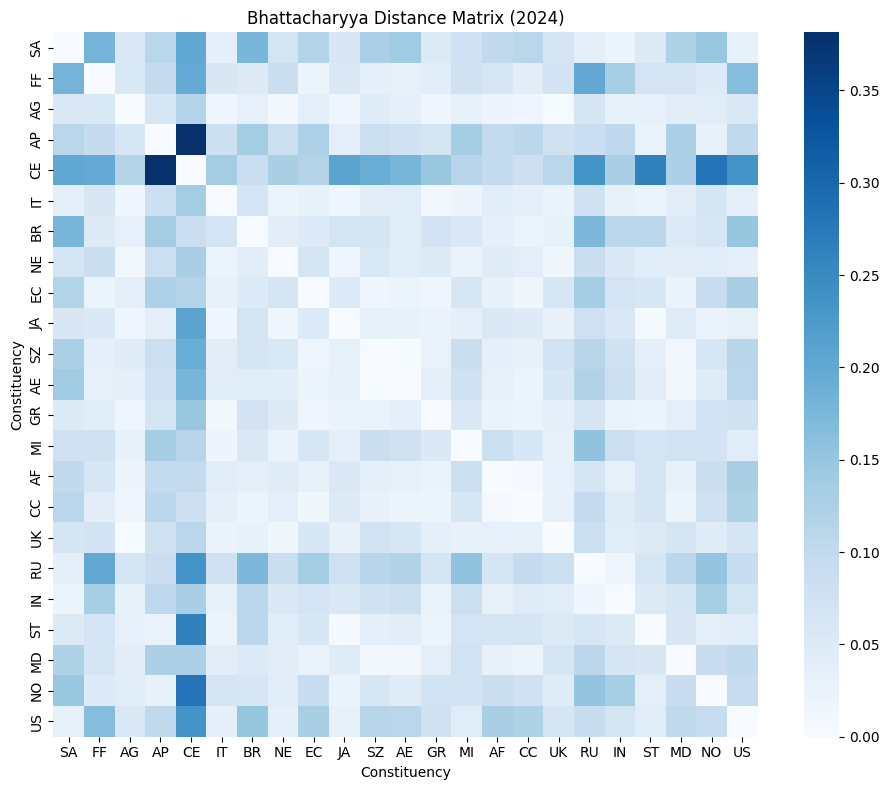

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    distance_matrix,
    xticklabels=labels,
    yticklabels=labels,
    cmap='Blues',  # Darker = larger distance (less similar)
    square=True
)
plt.title(f'Bhattacharyya Distance Matrix ({target_period})')
plt.xlabel('Constituency')
plt.ylabel('Constituency')
plt.tight_layout()
plt.show()